<a href="https://colab.research.google.com/github/Taniya1701/CSL701-CS06_Machine-Learning-Lab/blob/main/Experiments%20and%20Mini-Project/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


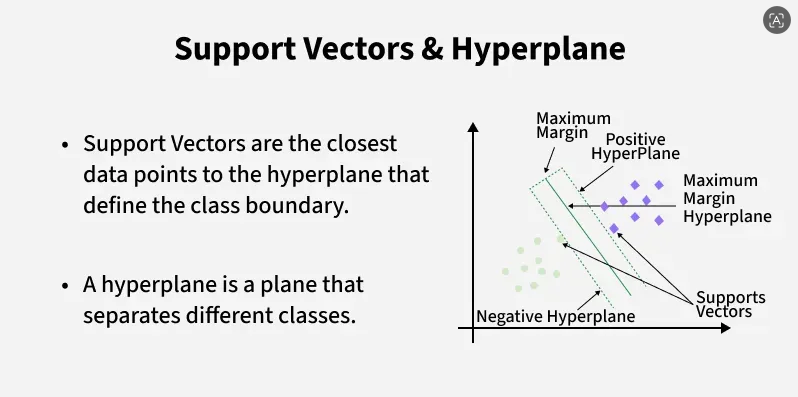
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Load the Iris dataset from sklearn
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Task 2: Explore the Dataset

In [3]:
# Display the shape of the dataset
print('Dataset shape:', df.shape)

# Display information about the dataset (data types, non-null values)
print('\nDataset info:')
df.info()

# Display descriptive statistics of the dataset
print('\nDataset descriptive statistics:')
df.describe(include='all')

Dataset shape: (150, 5)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Dataset descriptive statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [4]:
# Define features (X) and target (y)
X = df.drop('species', axis=1) # All columns except 'species'
y = df['species'] # The 'species' column is the target

print('Features (X) shape:', X.shape)
print('Target (y) shape:', y.shape)
print('\nFirst 5 rows of X:')
print(X.head())
print('\nFirst 5 rows of y:')
print(y.head())

Features (X) shape: (150, 4)
Target (y) shape: (150,)

First 5 rows of X:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

First 5 rows of y:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training features and transform both training and testing features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('X_train_scaled shape:', X_train_scaled.shape)
print('X_test_scaled shape:', X_test_scaled.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)


X_train_scaled shape: (120, 4)
X_test_scaled shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [6]:
from sklearn.svm import SVC

# Create an SVM model with a linear kernel
svm_linear = SVC(kernel='linear', random_state=42)

# Train the model
svm_linear.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_linear = svm_linear.predict(X_test_scaled)

print('Linear SVM predictions (first 5):', y_pred_linear[:5])

Linear SVM predictions (first 5): ['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa']


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate Accuracy
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f'Linear SVM Accuracy: {accuracy_linear:.4f}')

# Generate Confusion Matrix
conf_matrix_linear = confusion_matrix(y_test, y_pred_linear)
print('\nConfusion Matrix (Linear SVM):\n', conf_matrix_linear)

# Generate Classification Report
class_report_linear = classification_report(y_test, y_pred_linear)
print('\nClassification Report (Linear SVM):\n', class_report_linear)

Linear SVM Accuracy: 1.0000

Confusion Matrix (Linear SVM):
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report (Linear SVM):
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

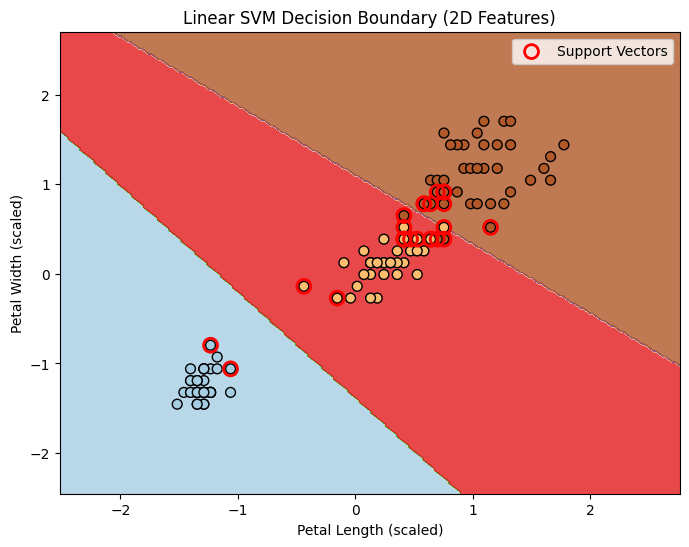

In [8]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Create the 2-D Dataset using 'petal length (cm)' and 'petal width (cm)'
X_2d = df[['petal length (cm)', 'petal width (cm)']]
y_2d = df['species']

# Split the 2-D data into training and testing sets
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d)

# Scale the 2-D features
scaler_2d = StandardScaler()
X_train_scaled_2d = scaler_2d.fit_transform(X_train_2d)
X_test_scaled_2d = scaler_2d.transform(X_test_2d)

# Train SVM with linear kernel on 2-D data
svm_linear_2d = SVC(kernel='linear', random_state=42)
svm_linear_2d.fit(X_train_scaled_2d, y_train_2d)

# Function to plot decision boundary
def plot_decision_boundary(X_scaled, y, model, title):
    plt.figure(figsize=(8, 6))

    # Create a meshgrid to plot decision boundaries
    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predict class for each point in the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Map string labels to numerical values for contour plotting
    unique_labels = np.unique(y)
    label_to_int = {label: i for i, label in enumerate(unique_labels)}
    Z_int = np.array([label_to_int[label] for label in Z.ravel()]).reshape(xx.shape)
    y_int = np.array([label_to_int[label] for label in y])

    # Plot decision boundaries and margins
    plt.contourf(xx, yy, Z_int, alpha=0.8, cmap=plt.cm.Paired)
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_int, cmap=plt.cm.Paired, s=50, edgecolors='k')

    # Plot support vectors if available (for SVC)
    if hasattr(model, 'support_vectors_'):
        plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                    s=100, facecolors='none', edgecolors='red', linewidth=2, label='Support Vectors')

    plt.xlabel('Petal Length (scaled)')
    plt.ylabel('Petal Width (scaled)')
    plt.title(title)
    plt.legend()
    plt.show()

# Plot the Linear SVM decision boundary
plot_decision_boundary(X_train_scaled_2d, y_train_2d, svm_linear_2d, 'Linear SVM Decision Boundary (2D Features)')

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

/tmp/ipykernel_2900/3659857095.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


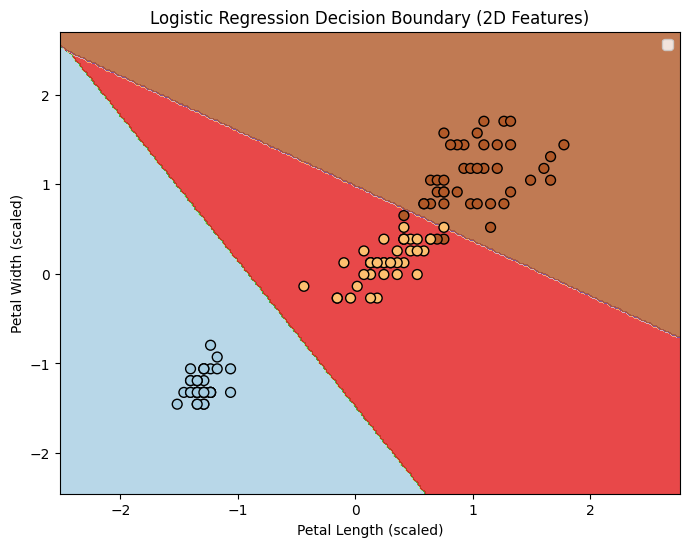

In [9]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model on 2-D data
log_reg_2d = LogisticRegression(random_state=42)
log_reg_2d.fit(X_train_scaled_2d, y_train_2d)

# Plot the Logistic Regression decision boundary
plot_decision_boundary(X_train_scaled_2d, y_train_2d, log_reg_2d, 'Logistic Regression Decision Boundary (2D Features)')

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

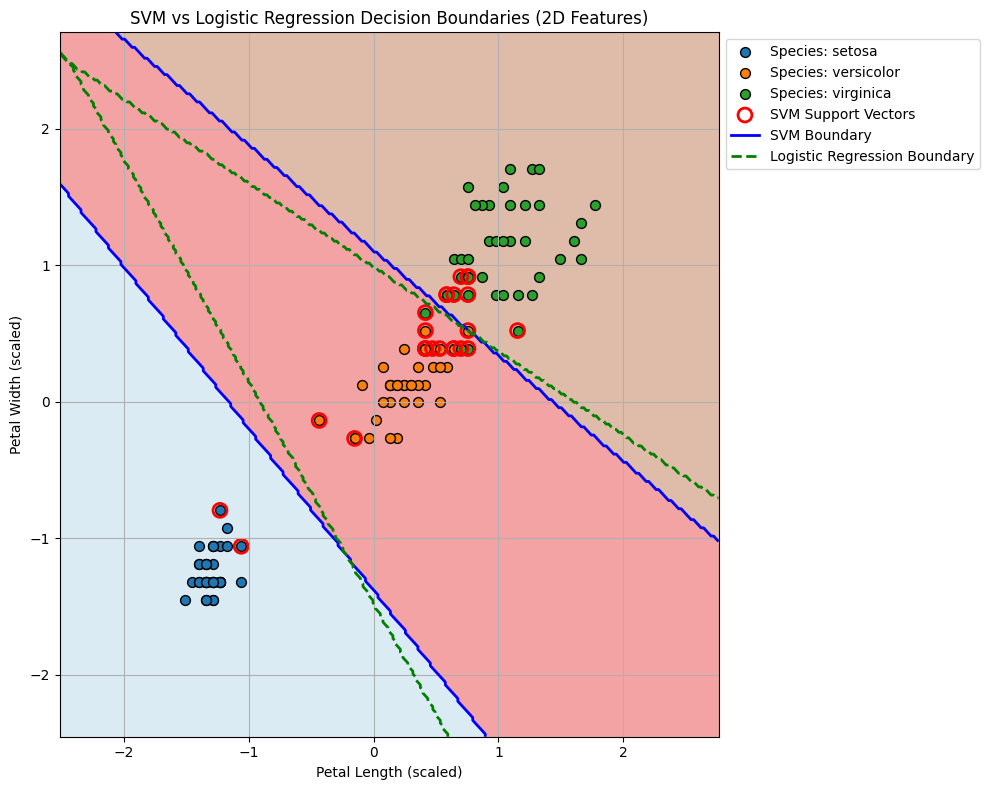

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

def plot_combined_decision_boundaries(X_scaled, y, svm_model, log_reg_model, title):
    plt.figure(figsize=(10, 8))

    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predict for SVM
    Z_svm = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z_svm = Z_svm.reshape(xx.shape)

    # Predict for Logistic Regression
    Z_log_reg = log_reg_model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z_log_reg = Z_log_reg.reshape(xx.shape)

    unique_labels = np.unique(y)
    label_to_int = {label: i for i, label in enumerate(unique_labels)}
    y_int = np.array([label_to_int[label] for label in y])

    # Plot initial filled regions for SVM (lighter alpha)
    Z_svm_int = np.array([label_to_int[label] for label in Z_svm.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z_svm_int, alpha=0.4, cmap=plt.cm.Paired)

    # Plot data points with proper labels for legend
    for label_val, label_int in label_to_int.items():
        idx = (y_int == label_int)
        plt.scatter(X_scaled[idx, 0], X_scaled[idx, 1],
                    label=f'Species: {label_val}', s=50, edgecolors='k') # Removed cmap as 'c' is not provided

    # Plot SVM decision boundaries (lines)
    plt.contour(xx, yy, Z_svm_int, colors='blue', linestyles='-', levels=np.arange(len(unique_labels)) - 0.5, linewidths=2)

    # Define Z_log_reg_int here
    Z_log_reg_int = np.array([label_to_int[label] for label in Z_log_reg.ravel()]).reshape(xx.shape)

    # Plot Logistic Regression decision boundaries (lines)
    plt.contour(xx, yy, Z_log_reg_int, colors='green', linestyles='--', levels=np.arange(len(unique_labels)) - 0.5, linewidths=2)

    # Plot support vectors if available (for SVM)
    if hasattr(svm_model, 'support_vectors_'):
        plt.scatter(svm_model.support_vectors_[:, 0], svm_model.support_vectors_[:, 1],
                    s=100, facecolors='none', edgecolors='red', linewidth=2, label='SVM Support Vectors')

    # Create custom legend handles for the decision boundaries
    svm_line = Line2D([0], [0], color='blue', linestyle='-', lw=2, label='SVM Boundary')
    log_reg_line = Line2D([0], [0], color='green', linestyle='--', lw=2, label='Logistic Regression Boundary')

    # Get existing handles and labels, then add custom ones
    handles, labels = plt.gca().get_legend_handles_labels()
    handles.extend([svm_line, log_reg_line])
    labels.extend(['SVM Boundary', 'Logistic Regression Boundary'])

    plt.xlabel('Petal Length (scaled)')
    plt.ylabel('Petal Width (scaled)')
    plt.title(title)
    plt.legend(handles=handles, labels=labels, loc='upper left', bbox_to_anchor=(1, 1)) # Place legend outside to avoid overlap
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call the combined plotting function
plot_combined_decision_boundaries(X_train_scaled_2d, y_train_2d, svm_linear_2d, log_reg_2d,
                                  'SVM vs Logistic Regression Decision Boundaries (2D Features)')

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print('--- Performance Comparison (2D Features) ---')

# --- Linear SVM (2D) Evaluation ---
# Make predictions for the 2D SVM model on the 2D test data
y_pred_svm_2d = svm_linear_2d.predict(X_test_scaled_2d)

print('\n--- Linear SVM (2D) Performance ---')
accuracy_svm_2d = accuracy_score(y_test_2d, y_pred_svm_2d)
print(f'Accuracy (Linear SVM 2D): {accuracy_svm_2d:.4f}')

conf_matrix_svm_2d = confusion_matrix(y_test_2d, y_pred_svm_2d)
print('\nConfusion Matrix (Linear SVM 2D):\n', conf_matrix_svm_2d)

class_report_svm_2d = classification_report(y_test_2d, y_pred_svm_2d)
print('\nClassification Report (Linear SVM 2D):\n', class_report_svm_2d)

# --- Logistic Regression (2D) Evaluation ---
# Make predictions for the 2D Logistic Regression model on the 2D test data
y_pred_log_reg_2d = log_reg_2d.predict(X_test_scaled_2d)

print('\n--- Logistic Regression (2D) Performance ---')
accuracy_log_reg_2d = accuracy_score(y_test_2d, y_pred_log_reg_2d)
print(f'Accuracy (Logistic Regression 2D): {accuracy_log_reg_2d:.4f}')

conf_matrix_log_reg_2d = confusion_matrix(y_test_2d, y_pred_log_reg_2d)
print('\nConfusion Matrix (Logistic Regression 2D):\n', conf_matrix_log_reg_2d)

class_report_log_reg_2d = classification_report(y_test_2d, y_pred_log_reg_2d)
print('\nClassification Report (Logistic Regression 2D):\n', class_report_log_reg_2d)

--- Performance Comparison (2D Features) ---

--- Linear SVM (2D) Performance ---
Accuracy (Linear SVM 2D): 0.9333

Confusion Matrix (Linear SVM 2D):
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report (Linear SVM 2D):
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


--- Logistic Regression (2D) Performance ---
Accuracy (Logistic Regression 2D): 0.9333

Confusion Matrix (Logistic Regression 2D):
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report (Logistic Regression 2D):
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virg

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.